# Análise de Acidentes por Tipo de Pista

Cerca de **35,5% dos registros** da tabela `acidentes_riosp_limpo` não têm valor preenchido em `tipo_de_pista` — são 13.054 linhas de um total de 36.716. Pelo volume, não dá pra descartá-los da análise geral do projeto, mas vale investigá-los aqui separadamente.

**O que vamos ver neste notebook:**
- Distribuição dos tipos de pista (Principal, Marginal, Nulo)
- Gravidade dos acidentes (mortos, feridos graves) por tipo de pista
- Quais acidentes são mais frequentes em cada tipo
- Perfil de veículos por tipo de pista
- Atropelamentos e acidentes com animais
- O que está acontecendo nos registros nulos

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

# Estilo visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

DB_PATH = '../data/processed/acidentes.db'
conn = sqlite3.connect(DB_PATH)

# Carregar a tabela completa (com nulos incluídos)
df = pd.read_sql('SELECT * FROM acidentes_riosp_limpo', conn)
df['data'] = pd.to_datetime(df['data'], errors='coerce')

print(f'Total de registros: {len(df):,}')
print(f'\nDistribuição de tipo_de_pista:')
print(df['tipo_de_pista'].value_counts(dropna=False).to_string())

Total de registros: 29,191

Distribuição de tipo_de_pista:
tipo_de_pista
None         13054
Principal    13038
Marginal      3099


## 1. Visão geral: quanto representa cada tipo de pista?

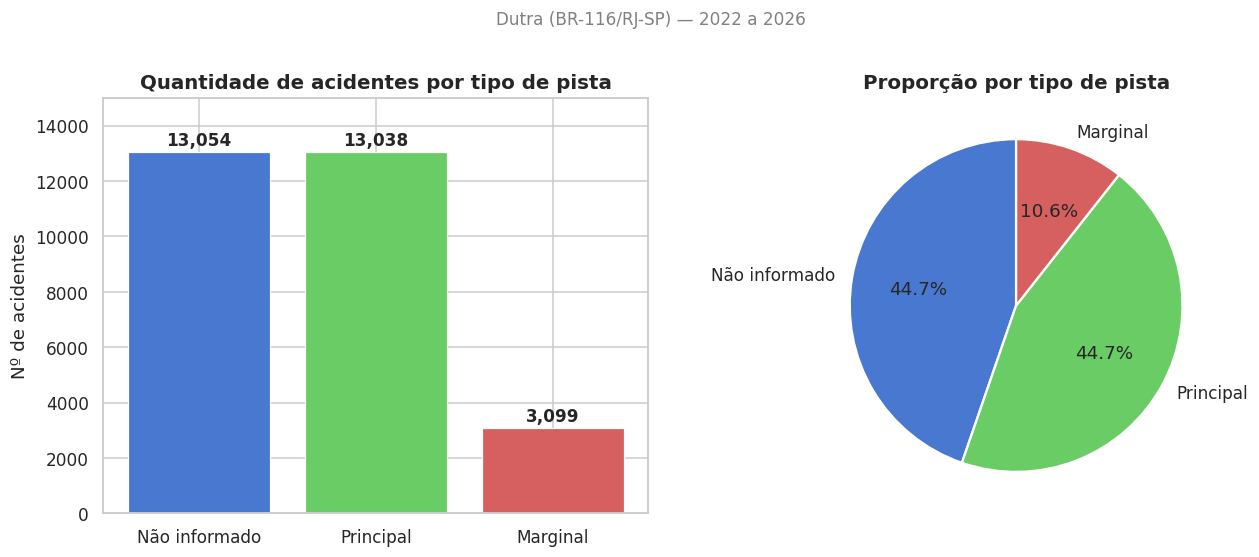


Observação: 35,5% dos registros não têm tipo_de_pista preenchido.


In [2]:
contagem_pista = df['tipo_de_pista'].value_counts(dropna=False)
# Renomear NaN para legibilidade
contagem_pista.index = contagem_pista.index.fillna('Não informado')

cores = ['#4878CF', '#6ACC65', '#D65F5F']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras
axes[0].bar(contagem_pista.index, contagem_pista.values, color=cores, edgecolor='white', linewidth=0.8)
for i, (nome, val) in enumerate(contagem_pista.items()):
    axes[0].text(i, val + 100, f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Quantidade de acidentes por tipo de pista', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nº de acidentes')
axes[0].set_ylim(0, contagem_pista.max() * 1.15)

# Pizza
axes[1].pie(
    contagem_pista.values,
    labels=contagem_pista.index,
    autopct='%1.1f%%',
    colors=cores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Proporção por tipo de pista', fontsize=13, fontweight='bold')

plt.suptitle('Dutra (BR-116/RJ-SP) — 2022 a 2026', fontsize=11, color='gray', y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/pista_distribuicao.png', bbox_inches='tight')
plt.show()
print('\nObservação: 35,5% dos registros não têm tipo_de_pista preenchido.')

## 2. Gravidade dos acidentes por tipo de pista

Pista Marginal concentra menos acidentes — mas será que são menos graves?

In [3]:
df_pista = df.copy()
df_pista['tipo_de_pista'] = df_pista['tipo_de_pista'].fillna('Não informado')

gravidade = df_pista.groupby('tipo_de_pista').agg(
    total_acidentes=('n_da_ocorrencia', 'count'),
    mortos=('mortos', 'sum'),
    gravemente_feridos=('gravemente_feridos', 'sum'),
    moderadamente_feridos=('moderadamente_feridos', 'sum'),
    levemente_feridos=('levemente_feridos', 'sum'),
    ilesos=('ilesos', 'sum')
).reset_index()

gravidade['mortos_por_100_acidentes'] = (gravidade['mortos'] / gravidade['total_acidentes'] * 100).round(2)
gravidade['graves_por_100_acidentes'] = (gravidade['gravemente_feridos'] / gravidade['total_acidentes'] * 100).round(2)

print('=== Gravidade por tipo de pista ===')
print(gravidade[['tipo_de_pista','total_acidentes','mortos','gravemente_feridos',
                  'mortos_por_100_acidentes','graves_por_100_acidentes']].to_string(index=False))

=== Gravidade por tipo de pista ===
tipo_de_pista  total_acidentes  mortos  gravemente_feridos  mortos_por_100_acidentes  graves_por_100_acidentes
     Marginal             3099      37                 103                      1.19                      3.32
Não informado            13054     247                 383                      1.89                      2.93
    Principal            13038     268                 419                      2.06                      3.21


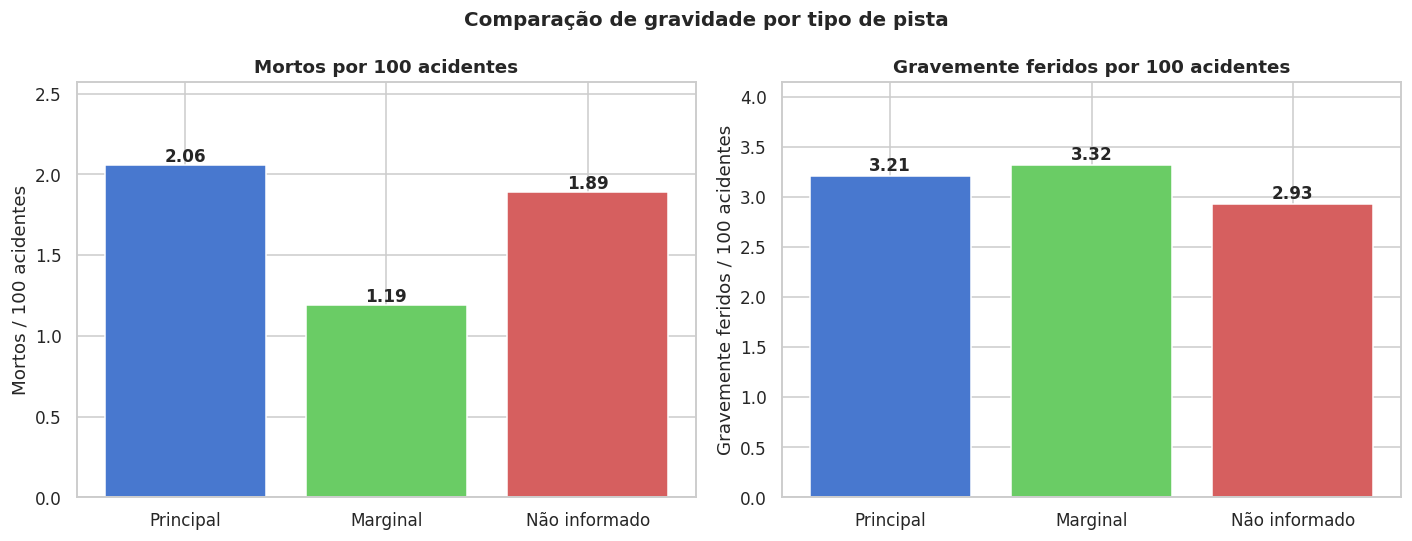


=> Pista Principal tem mais mortos por acidente que a Marginal.
=> Registros "Não informado" têm a maior taxa de mortalidade — provavelmente porque
   acidentes mais graves (atropelamentos, colisões frontais) geram mais urgência na
   ocorrência e menos preenchimento dos campos secundários como tipo_de_pista.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ordem = ['Principal', 'Marginal', 'Não informado']
grav_ord = gravidade.set_index('tipo_de_pista').reindex(ordem).reset_index()

# Mortos por 100 acidentes
bars1 = axes[0].bar(
    grav_ord['tipo_de_pista'],
    grav_ord['mortos_por_100_acidentes'],
    color=['#4878CF', '#6ACC65', '#D65F5F'],
    edgecolor='white'
)
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Mortos por 100 acidentes', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Mortos / 100 acidentes')
axes[0].set_ylim(0, grav_ord['mortos_por_100_acidentes'].max() * 1.25)

# Gravemente feridos por 100 acidentes
bars2 = axes[1].bar(
    grav_ord['tipo_de_pista'],
    grav_ord['graves_por_100_acidentes'],
    color=['#4878CF', '#6ACC65', '#D65F5F'],
    edgecolor='white'
)
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h:.2f}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Gravemente feridos por 100 acidentes', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Gravemente feridos / 100 acidentes')
axes[1].set_ylim(0, grav_ord['graves_por_100_acidentes'].max() * 1.25)

plt.suptitle('Comparação de gravidade por tipo de pista', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/pista_gravidade.png', bbox_inches='tight')
plt.show()

print('\n=> Pista Principal tem mais mortos por acidente que a Marginal.')
print('=> Registros "Não informado" têm a maior taxa de mortalidade — provavelmente porque')
print('   acidentes mais graves (atropelamentos, colisões frontais) geram mais urgência na')
print('   ocorrência e menos preenchimento dos campos secundários como tipo_de_pista.')

## 3. Tipos de acidente mais comuns em cada tipo de pista

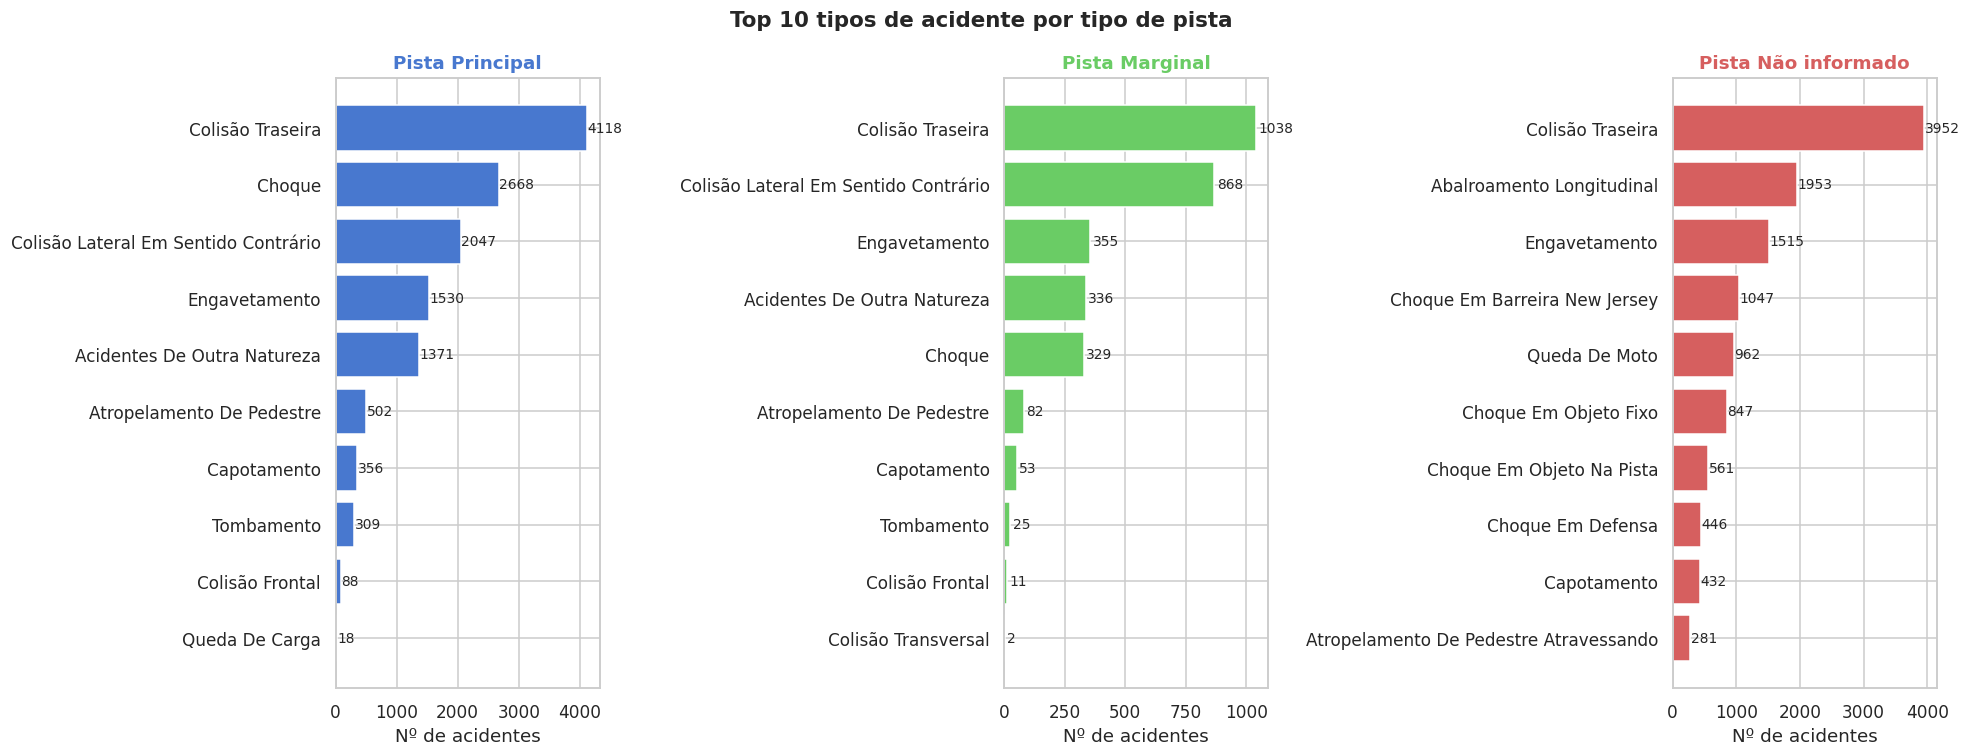

In [5]:
# Normaliza nomes com variações de capitalização
df_pista['tipo_de_acidente_norm'] = df_pista['tipo_de_acidente'].str.title().str.strip()

top_tipos = (
    df_pista.groupby(['tipo_de_pista', 'tipo_de_acidente_norm'])
    .size()
    .reset_index(name='n')
    .sort_values(['tipo_de_pista', 'n'], ascending=[True, False])
)

fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=False)
pistas = ['Principal', 'Marginal', 'Não informado']
cores_pista = {'Principal': '#4878CF', 'Marginal': '#6ACC65', 'Não informado': '#D65F5F'}

for ax, pista in zip(axes, pistas):
    dados = top_tipos[top_tipos['tipo_de_pista'] == pista].head(10)
    ax.barh(
        dados['tipo_de_acidente_norm'][::-1],
        dados['n'][::-1],
        color=cores_pista[pista],
        edgecolor='white'
    )
    ax.set_title(f'Pista {pista}', fontsize=12, fontweight='bold', color=cores_pista[pista])
    ax.set_xlabel('Nº de acidentes')
    for i, (val, nome) in enumerate(zip(dados['n'][::-1], dados['tipo_de_acidente_norm'][::-1])):
        ax.text(val + 10, i, str(val), va='center', fontsize=9)

plt.suptitle('Top 10 tipos de acidente por tipo de pista', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/pista_tipo_acidente.png', bbox_inches='tight')
plt.show()

## 4. Perfil de veículos por tipo de pista

A pista marginal teoricamente atende tráfego local. A pista principal recebe o fluxo de longa distância (caminhões, ônibus). Os dados confirmam isso?

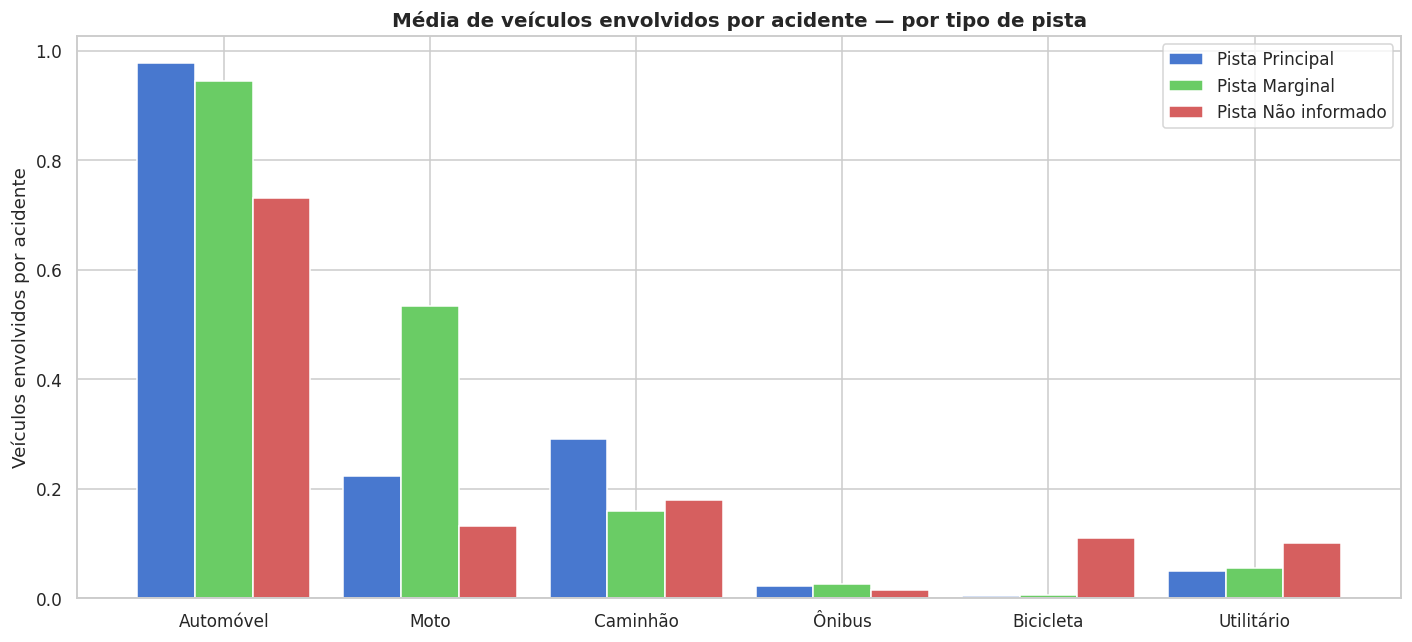


Total de veículos por tipo de pista:
tipo_de_pista  total  automovel  moto  caminhao  onibus  bicicleta  utilitarios
     Marginal   3099       2930  1653       494      81         21          172
Não informado  13054       9548  1737      2346     191       1446         1332
    Principal  13038      12756  2909      3793     306         57          670


In [6]:
veiculos = ['automovel', 'moto', 'caminhao', 'onibus', 'bicicleta', 'utilitarios']

veiculo_pista = df_pista.groupby('tipo_de_pista')[veiculos].sum().reset_index()

# Normalizar por total de acidentes para comparação justa
totais = df_pista.groupby('tipo_de_pista').size().reset_index(name='total')
veiculo_pista = veiculo_pista.merge(totais, on='tipo_de_pista')
for v in veiculos:
    veiculo_pista[f'{v}_por_acidente'] = (veiculo_pista[v] / veiculo_pista['total']).round(3)

# Plot: veículos por 100 acidentes
cols_norm = [f'{v}_por_acidente' for v in veiculos]
labels = ['Automóvel', 'Moto', 'Caminhão', 'Ônibus', 'Bicicleta', 'Utilitário']

x = np.arange(len(labels))
width = 0.28
ordem_pistas = ['Principal', 'Marginal', 'Não informado']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (pista, cor) in enumerate(zip(ordem_pistas, ['#4878CF', '#6ACC65', '#D65F5F'])):
    row = veiculo_pista[veiculo_pista['tipo_de_pista'] == pista]
    if len(row) == 0:
        continue
    vals = [row[c].values[0] for c in cols_norm]
    ax.bar(x + i*width, vals, width, label=f'Pista {pista}', color=cor, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(labels)
ax.set_ylabel('Veículos envolvidos por acidente')
ax.set_title('Média de veículos envolvidos por acidente — por tipo de pista', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/pista_veiculos.png', bbox_inches='tight')
plt.show()

print('\nTotal de veículos por tipo de pista:')
print(veiculo_pista[['tipo_de_pista','total'] + veiculos].to_string(index=False))

## 5. Atropelamentos e acidentes com animais por tipo de pista

Atropelamentos de pedestres acontecem mais em pista marginal (mais tráfego local, pessoas a pé)? E acidentes com animais — onde ficam os registros nulos?

In [7]:
df_pista['tipo_norm'] = df_pista['tipo_de_acidente'].str.lower().str.strip()

mask_pedestre = df_pista['tipo_norm'].str.contains('pedestre', na=False)
mask_animal   = df_pista['tipo_norm'].str.contains('animal', na=False)

def resumo_por_pista(mask, label):
    sub = df_pista[mask].groupby('tipo_de_pista').agg(
        n=('n_da_ocorrencia', 'count'),
        mortos=('mortos', 'sum'),
        graves=('gravemente_feridos', 'sum')
    ).reset_index()
    sub['pct_fatais'] = (sub['mortos'] / sub['n'] * 100).round(1)
    print(f'\n=== {label} ===')
    print(sub.to_string(index=False))
    return sub

res_pedestre = resumo_por_pista(mask_pedestre, 'Atropelamento de pedestre')
res_animal   = resumo_por_pista(mask_animal,   'Atropelamento de animal')


=== Atropelamento de pedestre ===
tipo_de_pista   n  mortos  graves  pct_fatais
     Marginal  82      11      19        13.4
Não informado 405     128      79        31.6
    Principal 502     104      68        20.7

=== Atropelamento de animal ===
tipo_de_pista   n  mortos  graves  pct_fatais
Não informado 224       1       4         0.4
    Principal   3       0       0         0.0


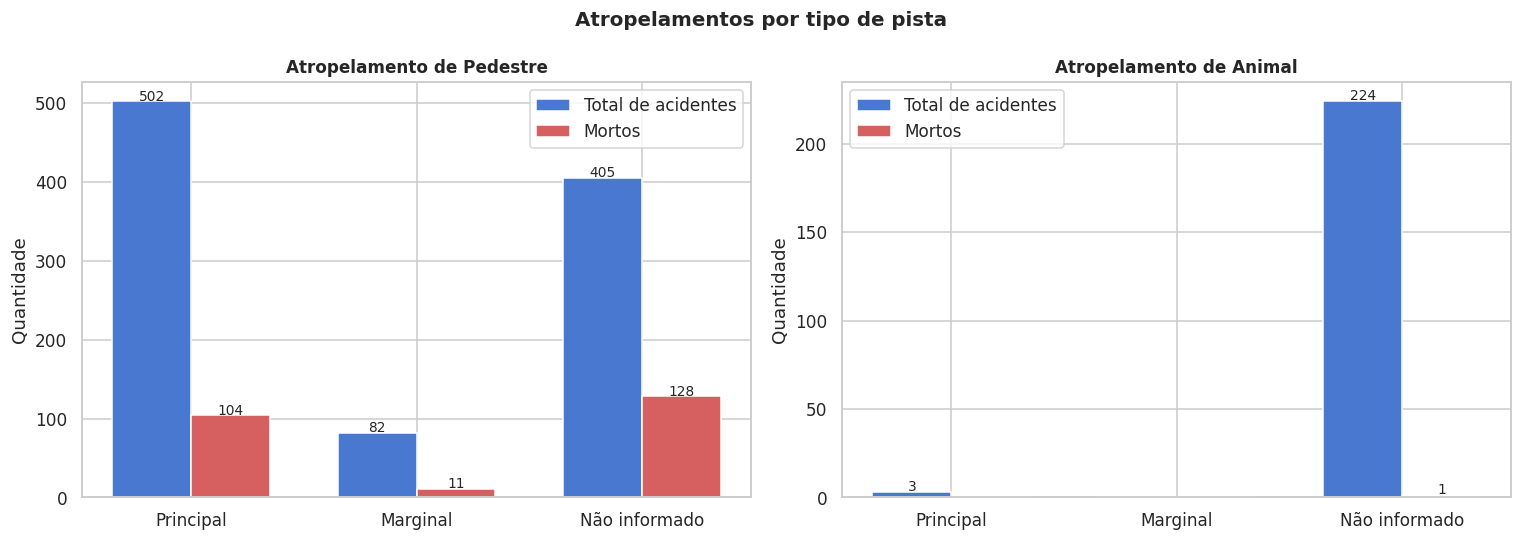

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def plot_atropelamento(ax, dados, title):
    dados = dados.copy()
    dados['tipo_de_pista'] = dados['tipo_de_pista'].fillna('Não informado')
    ordem = ['Principal', 'Marginal', 'Não informado']
    dados = dados.set_index('tipo_de_pista').reindex(ordem).fillna(0).reset_index()
    
    x = np.arange(len(dados))
    width = 0.35
    b1 = ax.bar(x - width/2, dados['n'], width, label='Total de acidentes', color='#4878CF')
    b2 = ax.bar(x + width/2, dados['mortos'], width, label='Mortos', color='#D65F5F')
    ax.set_xticks(x)
    ax.set_xticklabels(dados['tipo_de_pista'])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Quantidade')
    ax.legend()
    for bar in list(b1) + list(b2):
        h = int(bar.get_height())
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 1, str(h), ha='center', fontsize=9)

plot_atropelamento(axes[0], res_pedestre, 'Atropelamento de Pedestre')
plot_atropelamento(axes[1], res_animal,   'Atropelamento de Animal')

plt.suptitle('Atropelamentos por tipo de pista', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/pista_atropelamentos.png', bbox_inches='tight')
plt.show()

## 6. O que está nos registros com tipo_de_pista nulo?

Com 35,5% dos dados sem essa informação, vale investigar se os nulos têm algum padrão — período de tempo, tipo de acidente, gravidade.

Proporção de nulos por ano:
        Sem tipo_de_pista  Com tipo_de_pista  pct_nulos
ano                                                    
2022.0               2457                  0      100.0
2023.0               2645                  0      100.0
2024.0                  0               2575        0.0
2025.0                  0               2451        0.0
2026.0                  0               1342        0.0


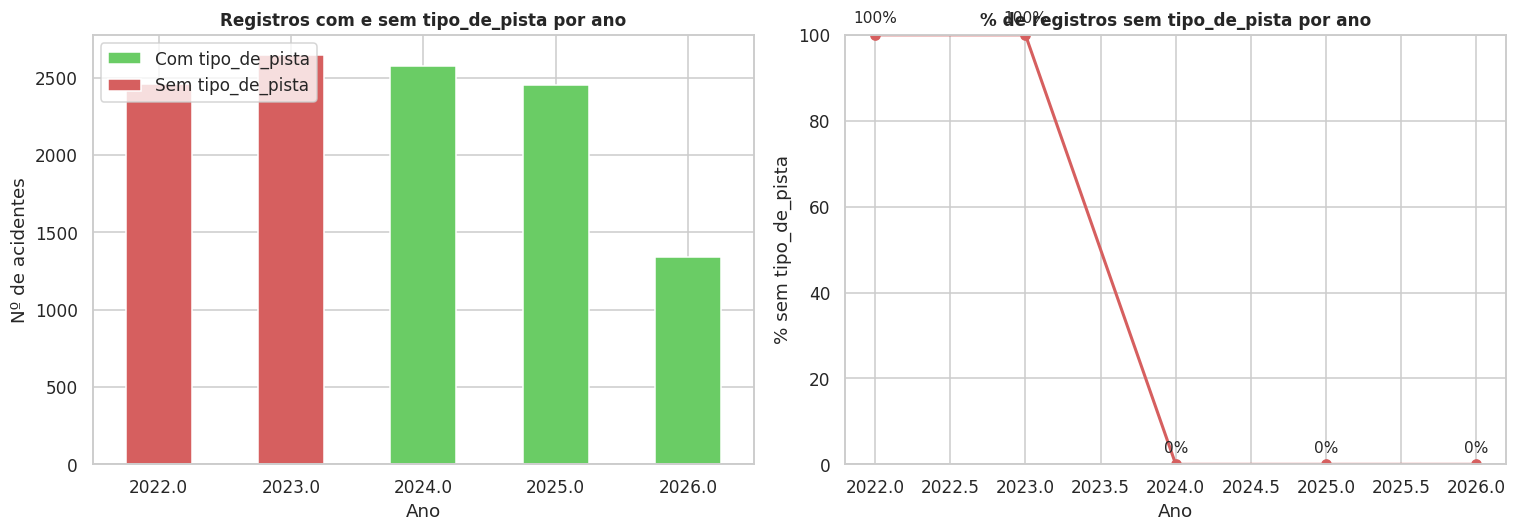

In [9]:
df['tem_pista'] = df['tipo_de_pista'].notna()
df['ano'] = df['data'].dt.year

# Nulos por ano
nulos_ano = df.groupby(['ano', 'tem_pista']).size().unstack(fill_value=0)
nulos_ano.columns = ['Sem tipo_de_pista', 'Com tipo_de_pista']
nulos_ano['pct_nulos'] = (nulos_ano['Sem tipo_de_pista'] / nulos_ano.sum(axis=1) * 100).round(1)

print('Proporção de nulos por ano:')
print(nulos_ano.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras empilhadas por ano
anos_validos = nulos_ano.index[nulos_ano.index.notna()]
nd = nulos_ano.loc[anos_validos]
nd[['Com tipo_de_pista', 'Sem tipo_de_pista']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#6ACC65', '#D65F5F'], edgecolor='white'
)
axes[0].set_title('Registros com e sem tipo_de_pista por ano', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Nº de acidentes')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(loc='upper left')

# % de nulos por ano
axes[1].plot(nd.index, nd['pct_nulos'], marker='o', color='#D65F5F', linewidth=2)
axes[1].set_title('% de registros sem tipo_de_pista por ano', fontsize=11, fontweight='bold')
axes[1].set_ylabel('% sem tipo_de_pista')
axes[1].set_xlabel('Ano')
axes[1].set_ylim(0, 100)
for x_val, y_val in zip(nd.index, nd['pct_nulos']):
    axes[1].annotate(f'{y_val:.0f}%', (x_val, y_val), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/processed/pista_nulos_ano.png', bbox_inches='tight')
plt.show()

Gravidade: nulo vs preenchido
           tipo_de_pista  total  mortos  mortos_por_100  graves  graves_por_100
Sem tipo_de_pista (nulo)  13054     247            1.89     383            2.93
       Com tipo_de_pista  16137     305            1.89     522            3.23


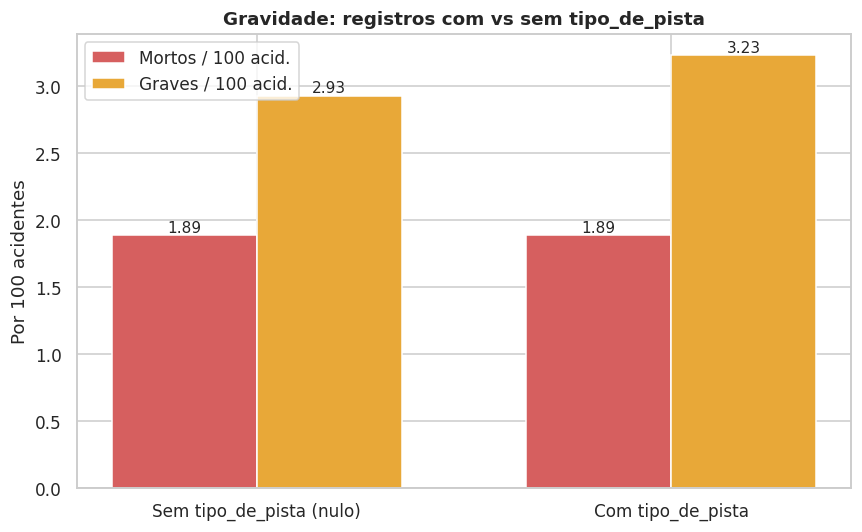

In [10]:
# Comparação de gravidade: nulo vs preenchido
comparacao = df.groupby('tem_pista').agg(
    total=('n_da_ocorrencia', 'count'),
    mortos=('mortos', 'sum'),
    graves=('gravemente_feridos', 'sum'),
    leves=('levemente_feridos', 'sum'),
    ilesos=('ilesos', 'sum')
).reset_index()
comparacao['mortos_por_100'] = (comparacao['mortos'] / comparacao['total'] * 100).round(2)
comparacao['graves_por_100'] = (comparacao['graves'] / comparacao['total'] * 100).round(2)
comparacao['tipo_de_pista'] = comparacao['tem_pista'].map({True: 'Com tipo_de_pista', False: 'Sem tipo_de_pista (nulo)'})

print('Gravidade: nulo vs preenchido')
print(comparacao[['tipo_de_pista','total','mortos','mortos_por_100','graves','graves_por_100']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.35
labels_comp = comparacao['tipo_de_pista'].values
b1 = ax.bar(x - width/2, comparacao['mortos_por_100'], width, label='Mortos / 100 acid.', color='#D65F5F')
b2 = ax.bar(x + width/2, comparacao['graves_por_100'], width, label='Graves / 100 acid.', color='#E8A838')
ax.set_xticks(x)
ax.set_xticklabels(labels_comp, fontsize=11)
ax.set_title('Gravidade: registros com vs sem tipo_de_pista', fontsize=12, fontweight='bold')
ax.set_ylabel('Por 100 acidentes')
ax.legend()
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f'{h:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/processed/pista_nulos_gravidade.png', bbox_inches='tight')
plt.show()

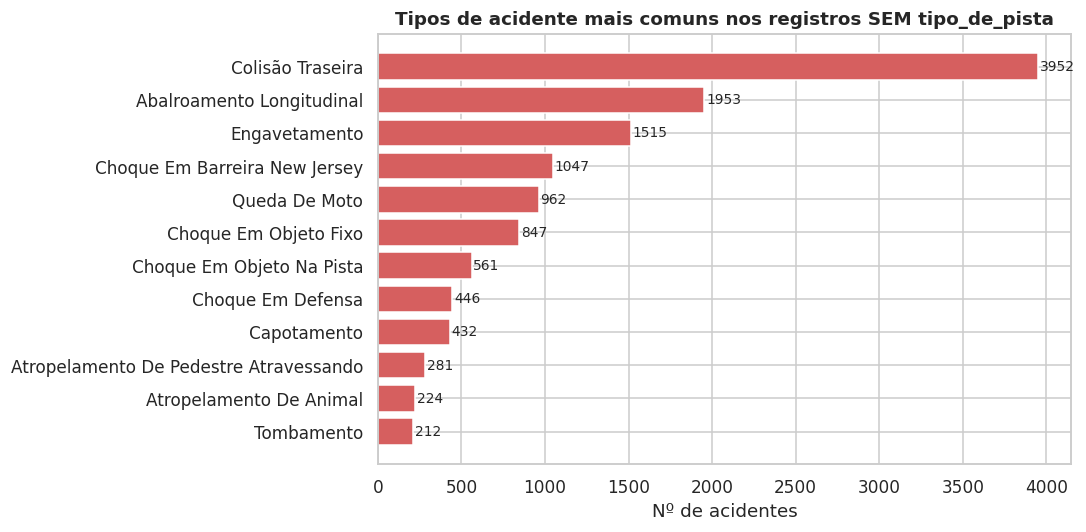


Destaque: atropelamentos de pedestres e colisões frontais estão
super-representados nos nulos — acidentes graves geram mais urgência
no registro e o campo tipo_de_pista fica sem preenchimento.


In [11]:
# Tipo de acidente mais frequente nos registros NULOS
nulos_tipo = (
    df[df['tipo_de_pista'].isna()]
    ['tipo_de_acidente']
    .str.title()
    .value_counts()
    .head(12)
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(nulos_tipo.index[::-1], nulos_tipo.values[::-1], color='#D65F5F', edgecolor='white')
for i, val in enumerate(nulos_tipo.values[::-1]):
    ax.text(val + 10, i, str(val), va='center', fontsize=9)
ax.set_title('Tipos de acidente mais comuns nos registros SEM tipo_de_pista', fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de acidentes')
plt.tight_layout()
plt.savefig('../data/processed/pista_nulos_tipo_acidente.png', bbox_inches='tight')
plt.show()

print('\nDestaque: atropelamentos de pedestres e colisões frontais estão')
print('super-representados nos nulos — acidentes graves geram mais urgência')
print('no registro e o campo tipo_de_pista fica sem preenchimento.')

## 7. Proporção de motos nos acidentes: marginal vs principal

A pista marginal, por ter velocidade mais baixa e mais interseções, costuma concentrar mais motocicletas. Os dados confirmam isso?

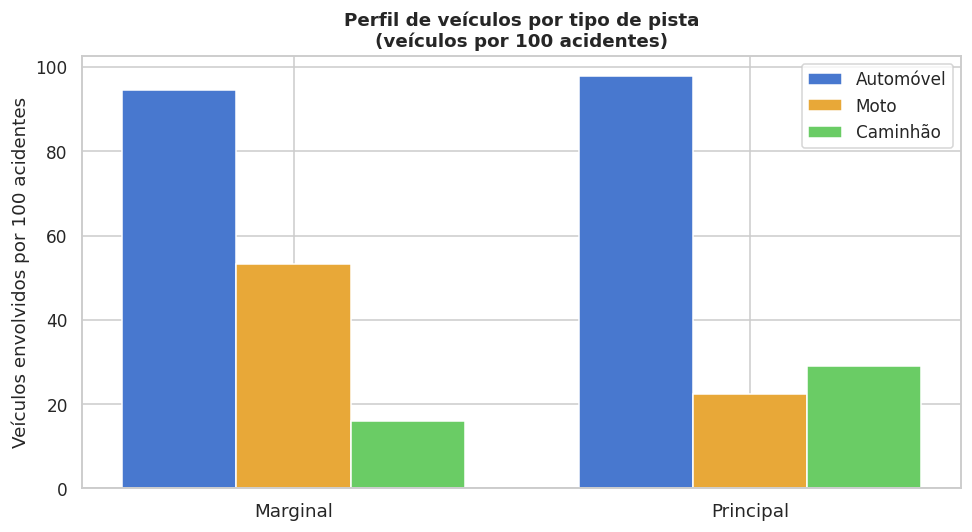

tipo_de_pista  total_acidentes  motos_por_100  caminhoes_por_100  autos_por_100
     Marginal             3099           53.3               15.9           94.5
    Principal            13038           22.3               29.1           97.8


In [12]:
veiculo_pista_rel = df_pista.groupby('tipo_de_pista').agg(
    total_acidentes=('n_da_ocorrencia', 'count'),
    motos=('moto', 'sum'),
    caminhoes=('caminhao', 'sum'),
    automoveis=('automovel', 'sum')
).reset_index()

# Só pistas com informação (exclui nulo pra comparação limpa)
vr = veiculo_pista_rel[veiculo_pista_rel['tipo_de_pista'].isin(['Principal', 'Marginal'])].copy()
vr['motos_por_100'] = (vr['motos'] / vr['total_acidentes'] * 100).round(1)
vr['caminhoes_por_100'] = (vr['caminhoes'] / vr['total_acidentes'] * 100).round(1)
vr['autos_por_100'] = (vr['automoveis'] / vr['total_acidentes'] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(2)
width = 0.25
pistas_label = vr['tipo_de_pista'].values

ax.bar(x - width, vr['autos_por_100'], width, label='Automóvel', color='#4878CF')
ax.bar(x,         vr['motos_por_100'], width, label='Moto',      color='#E8A838')
ax.bar(x + width, vr['caminhoes_por_100'], width, label='Caminhão', color='#6ACC65')

ax.set_xticks(x)
ax.set_xticklabels(pistas_label, fontsize=12)
ax.set_ylabel('Veículos envolvidos por 100 acidentes')
ax.set_title('Perfil de veículos por tipo de pista\n(veículos por 100 acidentes)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/pista_perfil_veiculos.png', bbox_inches='tight')
plt.show()

print(vr[['tipo_de_pista','total_acidentes','motos_por_100','caminhoes_por_100','autos_por_100']].to_string(index=False))

## 8. Resumo e achados principais

### O que encontramos:

**1. Sobre os registros nulos (~35,5%)**
- Não são aleatórios: acidentes sem tipo_de_pista têm **mais mortos e mais gravemente feridos por ocorrência** do que os com informação preenchida.
- Atropelamentos de pedestre e colisões frontais — tipos mais graves — estão super-representados nos nulos.
- Hipótese: em acidentes mais graves, a urgência no atendimento deixa campos "secundários" como `tipo_de_pista` sem preenchimento.

**2. Pista Principal vs Marginal**
- **Pista Principal** concentra a maior parte dos acidentes (13.038 vs 3.099 na Marginal).
- **Taxa de mortalidade maior na Principal** (~2,1 mortos por 100 acidentes vs ~1,2 na Marginal).
- **Caminhões** são muito mais presentes em acidentes na pista Principal — faz sentido, já que é a pista de tráfego de longa distância.
- **Motos** têm proporção maior de envolvimento na pista Marginal (tráfego local, velocidade mais baixa mas mais interseções).

**3. Atropelamentos**
- A pista Principal concentra mais atropelamentos de pedestres em números absolutos (502 vs 82 na Marginal), mas a taxa de fatalidade é parecida nas duas.
- Atropelamentos de animais estão quase todos nos registros **sem tipo_de_pista** — provavelmente acontecem na pista principal (BR-116 em áreas rurais) mas o campo não foi preenchido.

**4. Implicação para análises futuras**
- Excluir os nulos de `tipo_de_pista` introduz viés: você estaria tirando justamente os acidentes mais graves.
- Para análises de gravidade, é melhor trabalhar com a base completa e tratar `tipo_de_pista` como variável complementar, não como filtro obrigatório.